In [ ]:
import torch
import torch.nn as nn
from torch.optim import AdamW, Adam
from torch.nn import CrossEntropyLoss
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import StepLR,OneCycleLR
!pip install accelerate -U

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 7.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import re
import os
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
!pip install transformers
!pip install SentencePiece
!pip install git+https://github.com/PytorchLightning/pytorch-lightning.git@master --upgrade
#!pip install datasets
#from datasets import Dataset

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 77.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.8/236.8 kB 26.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 120.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.2 MB/s eta 0:00:00
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.0 MB/s eta 0:00:00
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Cloning https://github.com/PytorchLightning/pytorch-lightning.git (to revision master) to /tmp/pip-req-build-lvc8iy6d
  Running command git clone --filter=blob:none --quiet https://github.com/PytorchLightning/pytorch-lightning.git /tmp/pip-req-build-lvc8iy6d
  Resolved https://github.com/PytorchLightni

In [ ]:
import pytorch_lightning as pl
import transformers
#from transformers import AlbertModel , AlbertTokenizerFast, AlbertTokenizer

In [ ]:
def create_parent_dir():
    '''
    Creates parent directory structures and return their values
    '''
    data_path = './content'
    archive_path = data_path + '/data/'
    if not os.path.exists(data_path):
        print(f"Did not find {data_path} directory, creating one...")
        os.mkdir(data_path)
        os.mkdir(archive_path)
    elif not os.path.exists(archive_path):
        os.mkdir(archive_path)
    else:
        print("Required Parent Directory structure already in place")
    return data_path,archive_path

In [ ]:
create_parent_dir()

Did not find ./content directory, creating one...


('./content', './content/data/')

In [ ]:
!wget https://lp-prod-resources.s3.amazonaws.com/610/65202/2021-06-16-14-59-22/Khilnani_LP_real_news.csv

--2023-06-27 14:20:02--  https://lp-prod-resources.s3.amazonaws.com/610/65202/2021-06-16-14-59-22/Khilnani_LP_real_news.csv
Resolving lp-prod-resources.s3.amazonaws.com (lp-prod-resources.s3.amazonaws.com)... 52.92.162.113, 52.92.250.137, 52.218.220.131, ...
Connecting to lp-prod-resources.s3.amazonaws.com (lp-prod-resources.s3.amazonaws.com)|52.92.162.113|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 53582940 (51M) [application/octet-stream]
Saving to: ‘Khilnani_LP_real_news.csv’

Khilnani_LP_real_ne 100%[===================>]  51.10M  62.1MB/s    in 0.8s    

2023-06-27 14:20:03 (62.1 MB/s) - ‘Khilnani_LP_real_news.csv’ saved [53582940/53582940]



In [ ]:
!wget https://lp-prod-resources.s3.amazonaws.com/610/65202/2021-06-16-14-59-42/Khilnani_LP_fake_news.csv

--2023-06-27 14:20:03--  https://lp-prod-resources.s3.amazonaws.com/610/65202/2021-06-16-14-59-42/Khilnani_LP_fake_news.csv
Resolving lp-prod-resources.s3.amazonaws.com (lp-prod-resources.s3.amazonaws.com)... 52.92.196.217, 52.218.236.171, 52.218.196.130, ...
Connecting to lp-prod-resources.s3.amazonaws.com (lp-prod-resources.s3.amazonaws.com)|52.92.196.217|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 62789876 (60M) [application/octet-stream]
Saving to: ‘Khilnani_LP_fake_news.csv’

Khilnani_LP_fake_ne 100%[===================>]  59.88M  87.0MB/s    in 0.7s    

2023-06-27 14:20:04 (87.0 MB/s) - ‘Khilnani_LP_fake_news.csv’ saved [62789876/62789876]



In [ ]:
!ls -lL

total 113656
drwxr-xr-x 3 root root     4096 Jun 27 14:20 content
-rw-r--r-- 1 root root 62789876 Jun 16  2021 Khilnani_LP_fake_news.csv
-rw-r--r-- 1 root root 53582940 Jun 16  2021 Khilnani_LP_real_news.csv
drwxr-xr-x 1 root root     4096 Jun 23 13:41 sample_data


In [ ]:
with open("./Khilnani_LP_fake_news.csv", "r") as f:
  i = 0
  for line in f.readlines():
    print(line)
    i += 1
    if i > 2:
      break

title,text,subject,date

 Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year,  President Angry Pants tweeted.  2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America!  Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Y

In [ ]:
with open("./Khilnani_LP_real_news.csv", "r") as f:
  i = 0
  for line in f.readlines():
    print(line)
    i += 1
    if i > 2:
      break

title,text,subject,date

"As U.S. budget fight looms, Republicans flip their fiscal script","WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal conservative” on Sunday and urged budget restraint in 2018. In keeping with a sharp pivot under way among Republicans, U.S. Representative Mark Meadows, speaking on CBS’ “Face the Nation,” drew a hard line on federal spending, which lawmakers are bracing to do battle over in January. When they return from the holidays on Wednesday, lawmakers will begin trying to pass a federal budget in a fight likely to be linked to other issues, such as immigration policy, even as the November congressional election campaigns approach in which Republicans will seek to keep control of Congress. President Donald Trump and his Republicans want a big budget increase in military spending, while Democrats also want pro

In [ ]:
!ls -l

total 113656
drwxr-xr-x 3 root root     4096 Jun 27 14:20 content
-rw-r--r-- 1 root root 62789876 Jun 16  2021 Khilnani_LP_fake_news.csv
-rw-r--r-- 1 root root 53582940 Jun 16  2021 Khilnani_LP_real_news.csv
drwxr-xr-x 1 root root     4096 Jun 23 13:41 sample_data


In [ ]:
fake_n = './Khilnani_LP_fake_news.csv'
real_n = './Khilnani_LP_real_news.csv'

In [ ]:
fake_n, real_n

('./Khilnani_LP_fake_news.csv', './Khilnani_LP_real_news.csv')

In [ ]:
df_fake = pd.read_csv(fake_n)
df_real = pd.read_csv(real_n)

In [ ]:
df_fake

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"
...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016"
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016"
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"


In [ ]:
df_real

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"
...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017"
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017"
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017"
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017"


In [ ]:
df_real.columns, df_fake.columns

(Index(['title', 'text', 'subject', 'date'], dtype='object'),
 Index(['title', 'text', 'subject', 'date'], dtype='object'))

In [ ]:
df_real['label'] = 0
df_fake['label'] = 1

In [ ]:
df_real.columns, df_fake.columns

(Index(['title', 'text', 'subject', 'date', 'label'], dtype='object'),
 Index(['title', 'text', 'subject', 'date', 'label'], dtype='object'))

In [ ]:
df_news = pd.concat([df_real, df_fake], axis=0)

In [ ]:
df_news

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0
...,...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",1
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",1
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",1
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",1


In [ ]:
len(df_fake)+len(df_real)

44898

In [ ]:
df_news = df_news.sample(frac=1)

In [ ]:
len(df_news)

44898

In [ ]:
df_news

,title,text,subject,date,label
7392,Anxious world leaders seek clarity on Trump po...,LONDON (Reuters) - World leaders offered to wo...,politicsNews,"November 9, 2016",0
12406,Mozambique president replaces energy and forei...,MAPUTO (Reuters) - Mozambican President Filipe...,worldnews,"December 13, 2017",0
9767,Clinton sole presidential hopeful to attend As...,NEW YORK (Reuters) - U.S. Democrat Hillary Cli...,politicsNews,"April 27, 2016",0
9098,AMERICAN WORKERS Scr@wed Over By Outsourcing J...,American workers have suffered tremendously wi...,politics,"Dec 29, 2017",1
14803,BRILLIANT! A Great Patriot Destroys The Argume...,SENATOR JEFF SESSIONS has been such a beacon o...,politics,"Dec 12, 2015",1
...,...,...,...,...,...
17207,"Gaddafi son in good health, following politics...","TUNIS (Reuters) - Saif al-Islam Gaddafi, the m...",worldnews,"October 17, 2017",0
7914,U.S. Republican group hit by Russian-linked vi...,WASHINGTON (Reuters) - A U.S. Republican Party...,politicsNews,"October 6, 2016",0
7105,"Italy to push Iran trade ties, undaunted by Trump",ROME (Reuters) - Italy’s industry minister ple...,politicsNews,"November 22, 2016",0
5967,"Factbox: Trump names executives, labor officia...",WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,"January 27, 2017",0


In [ ]:
df_fn = df_news[['text', 'label']]

In [ ]:
df_fn

,text,label
7392,LONDON (Reuters) - World leaders offered to wo...,0
12406,MAPUTO (Reuters) - Mozambican President Filipe...,0
9767,NEW YORK (Reuters) - U.S. Democrat Hillary Cli...,0
9098,American workers have suffered tremendously wi...,1
14803,SENATOR JEFF SESSIONS has been such a beacon o...,1
...,...,...
17207,"TUNIS (Reuters) - Saif al-Islam Gaddafi, the m...",0
7914,WASHINGTON (Reuters) - A U.S. Republican Party...,0
7105,ROME (Reuters) - Italy’s industry minister ple...,0
5967,WASHINGTON (Reuters) - President Donald Trump ...,0


In [ ]:
import nltk

In [ ]:
!pip install tokenizers

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
from tokenizers.processors import TemplateProcessing

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
df_fn['text'] = df_fn['text'].apply(lambda x: x.lower())

<ipython-input-33-d402f474deb4>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fn['text'] = df_fn['text'].apply(lambda x: x.lower())


In [ ]:
df_fn

,text,label
7392,london (reuters) - world leaders offered to wo...,0
12406,maputo (reuters) - mozambican president filipe...,0
9767,new york (reuters) - u.s. democrat hillary cli...,0
9098,american workers have suffered tremendously wi...,1
14803,senator jeff sessions has been such a beacon o...,1
...,...,...
17207,"tunis (reuters) - saif al-islam gaddafi, the m...",0
7914,washington (reuters) - a u.s. republican party...,0
7105,rome (reuters) - italy’s industry minister ple...,0
5967,washington (reuters) - president donald trump ...,0


In [ ]:
df_fn['text'].iloc[2]

'new york (reuters) - u.s. democrat hillary clinton is the only presidential contender scheduled to attend a reception next week organized by a leading political association of asian americans and pacific islanders as she seeks to consolidate her support from minority voters. \xa0\xa0\xa0 the asian pacific american institute for congressional studies leadership network, a nonpartisan group that seeks to get asian americans elected to political office, said on wednesday that it had invited all presidential hopefuls to the event in washington, but clinton was the only one to accept. the campaigns of clinton’s democratic rival bernie sanders and republican hopeful ted cruz did not commit, and the campaign of republican front-runner donald trump campaign responded that he was unlikely to attend, floyd mori, president and chief executive of the leadership network said. republican john kasich’s campaign did not respond. \xa0\xa0\xa0 minority voters have provided a boost to clinton as she fen

In [ ]:
stopwords = nltk.corpus.stopwords.words('english')

In [ ]:
len(stopwords)

179

In [ ]:
df_fn['text'] = df_fn['text'].apply(lambda x: " ".join([word for word in x.split() if word not in stopwords]))

<ipython-input-38-491dd9c42ab0>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fn['text'] = df_fn['text'].apply(lambda x: " ".join([word for word in x.split() if word not in stopwords]))


In [ ]:
df_fn

,text,label
7392,london (reuters) - world leaders offered work ...,0
12406,maputo (reuters) - mozambican president filipe...,0
9767,new york (reuters) - u.s. democrat hillary cli...,0
9098,american workers suffered tremendously outsour...,1
14803,senator jeff sessions beacon common sense patr...,1
...,...,...
17207,"tunis (reuters) - saif al-islam gaddafi, promi...",0
7914,washington (reuters) - u.s. republican party w...,0
7105,rome (reuters) - italy’s industry minister ple...,0
5967,washington (reuters) - president donald trump ...,0


In [ ]:
df_fn['text'].iloc[2]

'new york (reuters) - u.s. democrat hillary clinton presidential contender scheduled attend reception next week organized leading political association asian americans pacific islanders seeks consolidate support minority voters. asian pacific american institute congressional studies leadership network, nonpartisan group seeks get asian americans elected political office, said wednesday invited presidential hopefuls event washington, clinton one accept. campaigns clinton’s democratic rival bernie sanders republican hopeful ted cruz commit, campaign republican front-runner donald trump campaign responded unlikely attend, floyd mori, president chief executive leadership network said. republican john kasich’s campaign respond. minority voters provided boost clinton fends challenge vermont senator sanders democratic nomination nov. 8 presidential election. african americans helped notch key wins states south carolina week maryland. asian americans pacific islanders smaller group, making 5.6

In [ ]:
df_fn['text'] = df_fn['text'].apply(lambda x: re.sub(r'[^\w\s]', '', x))

<ipython-input-41-4e3a9bf45cee>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fn['text'] = df_fn['text'].apply(lambda x: re.sub(r'[^\w\s]', '', x))


In [ ]:
df_fn

,text,label
7392,london reuters world leaders offered work don...,0
12406,maputo reuters mozambican president filipe ny...,0
9767,new york reuters us democrat hillary clinton ...,0
9098,american workers suffered tremendously outsour...,1
14803,senator jeff sessions beacon common sense patr...,1
...,...,...
17207,tunis reuters saif alislam gaddafi prominent ...,0
7914,washington reuters us republican party websit...,0
7105,rome reuters italys industry minister pledged...,0
5967,washington reuters president donald trump fri...,0


In [ ]:
df_fn['text'].iloc[2]

'new york reuters  us democrat hillary clinton presidential contender scheduled attend reception next week organized leading political association asian americans pacific islanders seeks consolidate support minority voters asian pacific american institute congressional studies leadership network nonpartisan group seeks get asian americans elected political office said wednesday invited presidential hopefuls event washington clinton one accept campaigns clintons democratic rival bernie sanders republican hopeful ted cruz commit campaign republican frontrunner donald trump campaign responded unlikely attend floyd mori president chief executive leadership network said republican john kasichs campaign respond minority voters provided boost clinton fends challenge vermont senator sanders democratic nomination nov 8 presidential election african americans helped notch key wins states south carolina week maryland asian americans pacific islanders smaller group making 56 percent population acc

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(df_fn['text'], df_fn['label'], test_size=0.2, shuffle=True, random_state=42, stratify=df_fn['label'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.1, shuffle=True, random_state=42, stratify=y_train)

In [ ]:
X_train, X_val, X_test

(20285    berlin reuters  german government considering ...
 19461                                                     
 20302    rainbows unicorn crowd decided complain gun ma...
 9326     according wired hackable security flaws softwa...
 4409     hilariously perfecthillary clinton already res...
                                ...                        
 6415     trump run white house major party candidate si...
 14890    london reuters  british prime minister theresa...
 6597     april 28 nearly 100 lawmakers sent letter mars...
 3438     berlin reuters  german government considering ...
 686      washington reuters  unease among republicans m...
 Name: text, Length: 32326, dtype: object,
 19921    wow moonbeam johnson addresses three issues fe...
 7903     chicago reuters  president barack obama friday...
 15179    onitsha nigeria reuters  police nigeria southe...
 12463    hanoi reuters  former chairman staterun vietna...
 13547    hillary clinton used cnn interview friday comp.

In [ ]:
y_train, y_val, y_test

(20285    0
 19461    1
 20302    1
 9326     1
 4409     1
         ..
 6415     1
 14890    0
 6597     1
 3438     0
 686      0
 Name: label, Length: 32326, dtype: int64,
 19921    1
 7903     0
 15179    0
 12463    0
 13547    1
         ..
 22350    1
 22925    1
 13980    1
 2992     1
 11394    0
 Name: label, Length: 8980, dtype: int64,
 20689    0
 13532    1
 19333    0
 21072    0
 2316     1
         ..
 7904     0
 18893    1
 11335    0
 18779    0
 19590    1
 Name: label, Length: 3592, dtype: int64)

In [ ]:
len(X_train), len(X_val), len(y_train), len(y_val), len(X_test), len(y_test)

(32326, 8980, 32326, 8980, 3592, 3592)

In [ ]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from transformers import PreTrainedTokenizerFast

In [ ]:
df_fn['text']

7392     london reuters  world leaders offered work don...
12406    maputo reuters  mozambican president filipe ny...
9767     new york reuters  us democrat hillary clinton ...
9098     american workers suffered tremendously outsour...
14803    senator jeff sessions beacon common sense patr...
                               ...                        
17207    tunis reuters  saif alislam gaddafi prominent ...
7914     washington reuters  us republican party websit...
7105     rome reuters  italys industry minister pledged...
5967     washington reuters  president donald trump fri...
16046    ripple wrote demand note front wife told rathe...
Name: text, Length: 44898, dtype: object

In [ ]:
!ls -l

total 113664
drwxr-xr-x 3 root root     4096 Jun 27 14:20 content
-rw-r--r-- 1 root root 62789876 Jun 16  2021 Khilnani_LP_fake_news.csv
-rw-r--r-- 1 root root 53582940 Jun 16  2021 Khilnani_LP_real_news.csv
drwxr-xr-x 1 root root     4096 Jun 23 13:41 sample_data


In [ ]:
df_fn['text'].to_csv('./token_train.csv', header=False, index=False)


In [ ]:
!ls -l

total 191232
drwxr-xr-x 3 root root     4096 Jun 27 14:20 content
-rw-r--r-- 1 root root 62789876 Jun 16  2021 Khilnani_LP_fake_news.csv
-rw-r--r-- 1 root root 53582940 Jun 16  2021 Khilnani_LP_real_news.csv
drwxr-xr-x 1 root root     4096 Jun 23 13:41 sample_data
-rw-r--r-- 1 root root 79428711 Jun 27 14:24 token_train.csv


In [ ]:
list_toks = df_fn['text'].tolist()

In [ ]:
len(list_toks)

44898

In [ ]:
list_toks[0]

'london reuters  world leaders offered work donald trump takes us president expressed anxiety handle problems middle east assertive russia whether carry number campaign threats several authoritarian rightwing leaders hailed billionaire businessman former tv show host leadership worlds powerful country odds tuesdays election china target trumps ire campaign appealed cooperation mexico also struck conciliatory tone despite trumps insults mexican migrants pledges build wall separate two countries south korea urged change policy north koreas nuclear tests trump previous political military experience said defeating democrat hillary clinton would seek common ground conflict united states allies election campaign voiced admiration russian president vladimir putin questioned central tenets nato military alliance suggested japan south korea develop nuclear weapons shoulder defense burden putin among first send trump congratulations ties washington moscow become strained conflicts ukraine syria 

In [ ]:
with open('./datafile.txt', 'w') as f:
  for news in list_toks:
    f.write(news)

In [ ]:
!ls -l

total 268764
drwxr-xr-x 3 root root     4096 Jun 27 14:20 content
-rw-r--r-- 1 root root 79382551 Jun 27 14:24 datafile.txt
-rw-r--r-- 1 root root 62789876 Jun 16  2021 Khilnani_LP_fake_news.csv
-rw-r--r-- 1 root root 53582940 Jun 16  2021 Khilnani_LP_real_news.csv
drwxr-xr-x 1 root root     4096 Jun 23 13:41 sample_data
-rw-r--r-- 1 root root 79428711 Jun 27 14:24 token_train.csv


In [ ]:
with open('./datafile_a.txt', 'a') as f:
  for news in list_toks:
    f.write(news)

In [ ]:
!ls -l

total 346288
drwxr-xr-x 3 root root     4096 Jun 27 14:20 content
-rw-r--r-- 1 root root 79382551 Jun 27 14:24 datafile_a.txt
-rw-r--r-- 1 root root 79382551 Jun 27 14:24 datafile.txt
-rw-r--r-- 1 root root 62789876 Jun 16  2021 Khilnani_LP_fake_news.csv
-rw-r--r-- 1 root root 53582940 Jun 16  2021 Khilnani_LP_real_news.csv
drwxr-xr-x 1 root root     4096 Jun 23 13:41 sample_data
-rw-r--r-- 1 root root 79428711 Jun 27 14:24 token_train.csv


In [ ]:
special_tokens=["[UNK]","[CLS]","[SEP]","[PAD]","[MASK]"]

In [ ]:
temp_proc= TemplateProcessing(
    single="[CLS] $A [SEP]",
    pair="[CLS] $A [SEP] $B:1 [SEP]:1",
    special_tokens=[
        ("[CLS]", special_tokens.index("[CLS]")),
        ("[SEP]", special_tokens.index("[SEP]")),
        ],
    )

In [ ]:
from tokenizers.normalizers import (Sequence,Lowercase, NFD, StripAccents)

In [ ]:
from tokenizers.decoders import BPEDecoder

In [ ]:
tokenizer = Tokenizer(BPE())

In [ ]:
tokenizer.normalizer = Sequence([NFD(),Lowercase(),StripAccents()])
tokenizer.pre_tokenizer = Whitespace()
tokenizer.decoder = BPEDecoder()
tokenizer.post_processor=temp_proc

In [ ]:
trainer = BpeTrainer(special_tokens= special_tokens)

In [ ]:
token_train_file = ['./datafile.txt']
tokenizer.train(token_train_file, trainer)

In [ ]:
tokenizer

In [ ]:
print(f"Trained vocab size: {tokenizer.get_vocab_size()}" )

Trained vocab size: 30000


In [ ]:
tokenizer.model.save('.')

['./vocab.json', './merges.txt']

In [ ]:
!wc -l merges.txt

29958 merges.txt


In [ ]:
!head -3 ./merges.txt

#version: 0.2
i n
e r


In [ ]:
tokenizer.save("MyBPETokenizer.json")

In [ ]:
!head -45 MyBPETokenizer.json

{
  "version": "1.0",
  "truncation": null,
  "padding": null,
  "added_tokens": [
    {
      "id": 0,
      "content": "[UNK]",
      "single_word": false,
      "lstrip": false,
      "rstrip": false,
      "normalized": false,
      "special": true
    },
    {
      "id": 1,
      "content": "[CLS]",
      "single_word": false,
      "lstrip": false,
      "rstrip": false,
      "normalized": false,
      "special": true
    },
    {
      "id": 2,
      "content": "[SEP]",
      "single_word": false,
      "lstrip": false,
      "rstrip": false,
      "normalized": false,
      "special": true
    },
    {
      "id": 3,
      "content": "[PAD]",
      "single_word": false,
      "lstrip": false,
      "rstrip": false,
      "normalized": false,
      "special": true
    },
    {
      "id": 4,
      "content": "[MASK]",
      "single_word": false,


In [ ]:
tokenizerFromFile = Tokenizer.from_file("MyBPETokenizer.json")

In [ ]:
sen_enc3 = tokenizerFromFile.encode("I like Hugging Face and Macbeth")
print(f"Output: {format(sen_enc3.tokens)}")

Output: ['[CLS]', 'i', 'like', 'hugging', 'face', 'and', 'mac', 'beth', '[SEP]']


In [ ]:
#####

In [ ]:
trained_tokenizer = PreTrainedTokenizerFast(tokenizer_object=tokenizerFromFile)

In [ ]:
trained_tokenizer

PreTrainedTokenizerFast(name_or_path='', vocab_size=30000, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='right', truncation_side='right', special_tokens={}, clean_up_tokenization_spaces=True)

In [ ]:
trained_tokenizer.add_special_tokens({'pad_token': '[PAD]'})

0

In [ ]:
trained_tokenizer(X_train.iloc[0], padding='max_length', truncation=True, max_length=64)

{'input_ids': [1, 3935, 316, 2295, 307, 3009, 2113, 1896, 1039, 999, 1971, 712, 499, 5472, 989, 2821, 534, 1807, 662, 642, 5190, 11068, 18547, 2995, 395, 18009, 891, 973, 724, 1414, 384, 3416, 10860, 3427, 395, 2722, 2659, 18029, 2295, 642, 2560, 2488, 3677, 1896, 723, 4589, 104, 187, 3376, 2822, 836, 1176, 209, 2995, 38, 650, 29, 650, 18009, 4273, 1278, 4377, 1936, 2], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [ ]:
df_tokens_train = pd.DataFrame()

In [ ]:
df_tokens_train['tokenized'] = X_train.apply(lambda x: trained_tokenizer(x, padding='max_length', truncation=True, max_length=64, return_tensors='pt'))

In [ ]:
df_tokens_train

,tokenized
20285,"[input_ids, token_type_ids, attention_mask]"
19461,"[input_ids, token_type_ids, attention_mask]"
20302,"[input_ids, token_type_ids, attention_mask]"
9326,"[input_ids, token_type_ids, attention_mask]"
4409,"[input_ids, token_type_ids, attention_mask]"
...,...
6415,"[input_ids, token_type_ids, attention_mask]"
14890,"[input_ids, token_type_ids, attention_mask]"
6597,"[input_ids, token_type_ids, attention_mask]"
3438,"[input_ids, token_type_ids, attention_mask]"


In [ ]:
df_tokens_train['tokenized'].iloc[0]['input_ids'].shape

torch.Size([1, 64])

In [ ]:
df_tokens_val = pd.DataFrame()

In [ ]:
df_tokens_val['tokenized'] = X_val.apply(lambda x: trained_tokenizer(x, padding='max_length', truncation=True, max_length=64, return_tensors='pt'))

In [ ]:
len(df_tokens_val), len(df_tokens_train)

(8980, 32326)

In [ ]:
df_tokens_test = pd.DataFrame()

In [ ]:
df_tokens_test['tokenized'] = X_test.apply(lambda x: trained_tokenizer(x, padding='max_length', truncation=True, max_length=64, return_tensors='pt'))

In [ ]:
len(df_tokens_test), len(df_tokens_val), len(df_tokens_train)

(3592, 8980, 32326)

In [ ]:
ckpt = 'roberta-base'

In [ ]:
from transformers import RobertaModel

In [ ]:
model = RobertaModel.from_pretrained(ckpt)
model

Some weights of the model checkpoint at roberta-base were not used when initializing RobertaModel: ['lm_head.layer_norm.bias', 'lm_head.bias', 'lm_head.layer_norm.weight', 'lm_head.dense.bias', 'lm_head.dense.weight']
- This IS expected if you are initializing RobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(50265, 768, padding_idx=1)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (dropou

In [ ]:
model.__dict__

{'training': False,
 '_parameters': OrderedDict(),
 '_buffers': OrderedDict(),
 '_non_persistent_buffers_set': set(),
 '_backward_pre_hooks': OrderedDict(),
 '_backward_hooks': OrderedDict(),
 '_is_full_backward_hook': None,
 '_forward_hooks': OrderedDict(),
 '_forward_hooks_with_kwargs': OrderedDict(),
 '_forward_pre_hooks': OrderedDict(),
 '_forward_pre_hooks_with_kwargs': OrderedDict(),
 '_state_dict_hooks': OrderedDict(),
 '_state_dict_pre_hooks': OrderedDict(),
 '_load_state_dict_pre_hooks': OrderedDict(),
 '_load_state_dict_post_hooks': OrderedDict(),
 '_modules': OrderedDict([('embeddings',
               RobertaEmbeddings(
                 (word_embeddings): Embedding(50265, 768, padding_idx=1)
                 (position_embeddings): Embedding(514, 768, padding_idx=1)
                 (token_type_embeddings): Embedding(1, 768)
                 (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
                 (dropout): Dropout(p=0.1, inplace=False)
           

In [ ]:
model(**df_tokens_train['tokenized'].iloc[0]).last_hidden_state.shape #['input_ids'], df_tokens_train['tokenized'].iloc[0]['token_type_ids'],  df_tokens_train['tokenized'].iloc[0]['attention_mask'])

torch.Size([1, 64, 768])

In [ ]:
input_ids = df_tokens_train['tokenized'].iloc[0]['input_ids']
attention_mask = df_tokens_train['tokenized'].iloc[0]['attention_mask']

In [ ]:
input_ids, attention_mask

(tensor([[    1,  3935,   316,  2295,   307,  3009,  2113,  1896,  1039,   999,
           1971,   712,   499,  5472,   989,  2821,   534,  1807,   662,   642,
           5190, 11068, 18547,  2995,   395, 18009,   891,   973,   724,  1414,
            384,  3416, 10860,  3427,   395,  2722,  2659, 18029,  2295,   642,
           2560,  2488,  3677,  1896,   723,  4589,   104,   187,  3376,  2822,
            836,  1176,   209,  2995,    38,   650,    29,   650, 18009,  4273,
           1278,  4377,  1936,     2]]),
 tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
          1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
          1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]))

In [ ]:
t0 = df_tokens_train['tokenized'].iloc[0]['input_ids']
t1 = df_tokens_train['tokenized'].iloc[1]['input_ids']
t2 = df_tokens_train['tokenized'].iloc[2]['input_ids']
ti = torch.cat([t0, t1, t2], dim=0)

In [ ]:
ti.shape

torch.Size([3, 64])

In [ ]:
a0 = df_tokens_train['tokenized'].iloc[0]['attention_mask']
a1 = df_tokens_train['tokenized'].iloc[1]['attention_mask']
a2 = df_tokens_train['tokenized'].iloc[2]['attention_mask']
am = torch.cat([a0, a1, a2], dim=0)

In [ ]:
am.shape

torch.Size([3, 64])

In [ ]:
ti.shape, am.shape, type(ti), type(am)

(torch.Size([3, 64]), torch.Size([3, 64]), torch.Tensor, torch.Tensor)

In [ ]:
model(input_ids=ti, attention_mask=am).last_hidden_state.shape

torch.Size([3, 64, 768])

In [ ]:
class fakenew_ds(Dataset):
  def __init__(self, tokens, labels):
    self.tokens = tokens
    self.labels = labels

  def __getitem__(self, idx):
    input_ids = self.tokens.iloc[idx]['input_ids'].squeeze()
    token_type_ids = self.tokens.iloc[idx]['token_type_ids'].squeeze()
    attention_mask = self.tokens.iloc[idx]['attention_mask'].squeeze()
    labels = torch.tensor(self.labels.iloc[idx]) #.type(torch.LongTensor)
    return input_ids, token_type_ids, attention_mask, labels

  def __len__(self):
    return len(self.labels)

In [ ]:
train_ds = fakenew_ds(df_tokens_train['tokenized'], y_train)
val_ds = fakenew_ds(df_tokens_val['tokenized'], y_val)

In [ ]:
test_ds = fakenew_ds(df_tokens_test['tokenized'], y_test)

In [ ]:
len(train_ds), len(val_ds), len(test_ds)

(32326, 8980, 3592)

In [ ]:
train_ds[0], val_ds[0]

((tensor([    1,  3935,   316,  2295,   307,  3009,  2113,  1896,  1039,   999,
           1971,   712,   499,  5472,   989,  2821,   534,  1807,   662,   642,
           5190, 11068, 18547,  2995,   395, 18009,   891,   973,   724,  1414,
            384,  3416, 10860,  3427,   395,  2722,  2659, 18029,  2295,   642,
           2560,  2488,  3677,  1896,   723,  4589,   104,   187,  3376,  2822,
            836,  1176,   209,  2995,    38,   650,    29,   650, 18009,  4273,
           1278,  4377,  1936,     2]),
  tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
          1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
          1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
  tensor(0)),
 (tensor([    1,  

In [ ]:
batch_size=32
train_dl = DataLoader(train_ds, shuffle=True, num_workers=os.cpu_count(), batch_size=batch_size)
valid_dl = DataLoader(val_ds, shuffle=False, num_workers=os.cpu_count(), batch_size=batch_size)

In [ ]:
test_dl = DataLoader(test_ds, shuffle=False, num_workers=os.cpu_count(), batch_size=batch_size)

In [ ]:
len(train_dl), len(valid_dl), len(train_ds)/32, len(val_ds)/32, len(test_ds)/32, len(test_dl)

(1011, 281, 1010.1875, 280.625, 112.25, 113)

In [ ]:
input_tokens, token_type_ids, attention_tokens , labels = next(iter(train_dl))

In [ ]:
input_tokens.shape, token_type_ids.shape, attention_tokens.shape, labels.shape

(torch.Size([32, 64]),
 torch.Size([32, 64]),
 torch.Size([32, 64]),
 torch.Size([32]))

In [ ]:
model(input_ids=input_tokens, attention_mask=attention_tokens).last_hidden_state.shape

torch.Size([32, 64, 768])

In [ ]:
model(input_tokens, attention_mask=attention_tokens).last_hidden_state.shape

torch.Size([32, 64, 768])

In [ ]:
class custom_roberta(torch.nn.Module):
  def __init__(self, embed_size, ckpt, num_labels):
    super().__init__()

    self.checkpoint = ckpt
    self.basemodel = RobertaModel.from_pretrained(self.checkpoint)
    self.flatten = nn.Flatten()
    self.classifier = nn.Sequential(
        nn.Linear(embed_size, embed_size, bias=False),
        nn.BatchNorm1d(embed_size),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Linear(embed_size, num_labels)
    )

  def forward(self, input_tokens, attention_tokens):

    x = self.basemodel(input_tokens, attention_mask=attention_tokens)
    x = self.flatten(x.last_hidden_state[:,0,:])
    x = self.classifier(x)

    return x

In [ ]:
embed_size = 768
ckpt = 'roberta-base'
num_labels = 2
model = custom_roberta(embed_size,ckpt,num_labels)

Some weights of the model checkpoint at roberta-base were not used when initializing RobertaModel: ['lm_head.layer_norm.bias', 'lm_head.bias', 'lm_head.layer_norm.weight', 'lm_head.dense.bias', 'lm_head.dense.weight']
- This IS expected if you are initializing RobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
model

custom_roberta(
  (basemodel): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): La

In [ ]:
model(input_tokens, attention_tokens)

tensor([[-1.4466e-01, -1.5939e-01],
        [ 5.9105e-01,  1.7131e-01],
        [ 4.7251e-01,  9.5229e-02],
        [-4.1580e-01, -1.4373e+00],
        [ 5.6461e-02,  5.5310e-01],
        [ 6.8347e-01,  1.6581e-01],
        [-2.9637e-01,  3.1578e-02],
        [ 4.6197e-01, -2.1992e-01],
        [-5.4345e-01, -2.2116e-01],
        [ 1.8725e-01, -6.3735e-01],
        [ 1.8129e-01, -1.4670e-01],
        [ 1.0956e+00, -6.4445e-01],
        [ 7.9440e-02,  1.4047e-01],
        [ 3.9733e-01,  8.6649e-02],
        [ 1.1223e-01,  2.5723e-01],
        [ 4.0588e-01, -2.9994e-01],
        [ 1.1351e+00, -9.8564e-01],
        [ 8.4641e-01,  1.0239e+00],
        [-3.0278e-01,  3.2879e-01],
        [-8.3430e-02,  1.5317e-01],
        [-5.1439e-01,  3.4155e-01],
        [ 1.5240e-04, -3.3084e-01],
        [ 3.7370e-01,  5.5603e-01],
        [ 7.1993e-01,  1.0663e-01],
        [-1.4762e-01,  2.9552e-01],
        [ 2.4772e-01,  1.8453e-01],
        [ 2.1050e-01,  2.4241e-01],
        [-4.2783e-01, -1.197

In [ ]:
model(input_tokens, attention_tokens).shape

torch.Size([32, 2])

In [ ]:
class Training():
    def __init__(self, model, optimizer, loss_fn, epochs, batch_size, train_gen, valid_gen, test_gen,
                len_train_ds, len_valid_ds, len_test_ds, device, labels_cat, oclr_sched=None, oclr=False, early_stop=True, patience=4):
        super().__init__()
        self.model = model.to(device)
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.epochs = epochs
        self.batch_size = batch_size
        self.train_generator = train_gen
        self.valid_generator = valid_gen
        self.test_generator = test_gen
        self.train_ds_size = len_train_ds
        self.valid_ds_size = len_valid_ds
        self.test_ds_size = len_test_ds
        self.train_history = {'loss': [], 'accuracy': [], 'f1': [], 'precision': [], 'recall': []}
        self.valid_history = {'loss': [], 'accuracy': [], 'f1': [], 'precision': [], 'recall': [], 'ckpt_name': []}
        self.early_stop_enabled = early_stop
        self.patience_level = patience
        self.device = device
        self.classes = labels_cat
        self.oclr = oclr
        if(self.oclr):
          self.oclr_sched = oclr_sched

    def train_step(self, input_tokens, token_type_ids, attention_tokens, train_label):
        self.model.train()
        output = self.model(input_tokens, attention_tokens)
        loss_value = self.loss_fn(output, train_label)
        self.optimizer.zero_grad()
        loss_value.backward()
        self.optimizer.step()
        if(self.oclr):
          self.oclr_sched.step()
        return output, loss_value  ## To be updated

    def test_step(self, input_tokens, token_type_ids, attention_tokens, validation_label):
        self.model.eval()
        with torch.inference_mode():
            val_output = self.model(input_tokens, attention_tokens)
            loss_value = self.loss_fn(val_output, validation_label)
        return val_output, loss_value ## To be updated



    def train(self, df):
        ds_len = self.train_ds_size
        gen = self.train_generator
        loss_epoch = 0
        accuracy = 0
        avg_epoch_loss = 0
        avg_accuracy = 0

        for input_ids, token_type_ids, attention_mask, y_batch in gen:
            y_batch = y_batch.type(torch.LongTensor)
            input_ids, token_type_ids, attention_mask, y_batch = input_ids.to(self.device), token_type_ids.to(self.device), attention_mask.to(self.device), y_batch.to(self.device)
            output, loss_value = self.train_step(input_ids, token_type_ids, attention_mask, y_batch)

            pred_labls = list(np.argmax(output.detach().cpu().numpy(), axis=1))
            temp_df = pd.DataFrame({'orig_label': list(y_batch.detach().cpu().numpy()), 'pred_label': pred_labls})
            df = pd.concat([df, temp_df])
            loss_epoch += loss_value.item()*y_batch.shape[0]
            accuracy += (np.array(pred_labls) == y_batch.detach().cpu().numpy()).sum().item()

        avg_epoch_loss = loss_epoch/ds_len
        avg_accuracy = accuracy/ds_len

        return df, avg_epoch_loss, avg_accuracy

    def test_validate(self,df,valid=True,train=False):
        if(valid):
            ds_len = self.valid_ds_size
            gen = self.valid_generator
        elif(train):
            ds_len = self.train_ds_size
            gen = self.train_generator
        else:
            ds_len = self.test_ds_size
            gen = self.test_generator
        loss_epoch = 0
        accuracy = 0
        avg_epoch_loss = 0
        avg_accuracy = 0

        for input_ids, token_type_ids, attention_mask, y_batch in gen:
            y_batch = y_batch.type(torch.LongTensor)
            input_ids, token_type_ids, attention_mask, y_batch = input_ids.to(self.device), token_type_ids.to(self.device), attention_mask.to(self.device), y_batch.to(self.device)
            output, loss_value = self.test_step(input_ids, token_type_ids, attention_mask, y_batch)

            pred_labls = list(np.argmax(output.detach().cpu().numpy(), axis=1))
            temp_df = pd.DataFrame({'orig_label': list(y_batch.detach().cpu().numpy()), 'pred_label': pred_labls})
            df = pd.concat([df, temp_df])
            loss_epoch += loss_value.item()*y_batch.shape[0]
            accuracy += (np.array(pred_labls) == y_batch.detach().cpu().numpy()).sum().item()
            #accuracy += (pred_labls == y_batch).sum().item()

        avg_epoch_loss = loss_epoch/ds_len
        avg_accuracy = accuracy/ds_len

        return df, avg_epoch_loss, avg_accuracy

    def train_model(self):
        for epoch in range(self.epochs):
            start_time = time.time()
            histdf_train = pd.DataFrame({'orig_label': [], 'pred_label': []})
            histdf_val   = pd.DataFrame({'orig_label': [], 'pred_label': []})
            df_train_cm, avg_epoch_train_loss, train_accuracy = self.train(histdf_train)
            df_val_cm, avg_epoch_val_loss, val_accuracy = self.test_validate(histdf_val)

            ##################################################################################
            #Following Code snippets calculate and update metric values
            ##################################################################################

            acc_class_train = self.update_metrics_on_epoch_end(df_train_cm, True, self.train_history, avg_epoch_train_loss, train_accuracy)
            acc_class_valid = self.update_metrics_on_epoch_end(df_val_cm, False, self.valid_history, avg_epoch_val_loss, val_accuracy)

            #Code for earlystopping ####
            la = self.valid_history['accuracy']
            if(self.early_stop_enabled):
                if (len(la) > 10):
                    exit_train_loop = self.early_stopping(self.patience_level)
                    if(exit_train_loop):
                        return self.train_history, self.valid_history

            ##Code for saving checkpoints
            if ((la[-1] >= 0.7) and (len(la) > 1)):
                if(la[-1] > max(la[0:-1])):
                    self.save_checkpoint(epoch, la[-1])
            elif ((la[-1] >= 0.7) and (len(la) == 1)):
                self.save_checkpoint(epoch, la[-1])
            torch.cuda.empty_cache()
            print(f'Epoch : {epoch}, Train Loss: {avg_epoch_train_loss}, Train Accuracy: {train_accuracy},\n Validation Loss: {avg_epoch_val_loss}, Validation Accuracy: {val_accuracy}')
            print(f'Time taken: {np.round((time.time() - start_time), 4)}')

        print(f'Training completed successfully. Loading best checkpoint weights ...')
        if len(self.valid_history['ckpt_name']) > 0:
            self.model.load_state_dict(torch.load(self.valid_history['ckpt_name'][-1]))
            print(f'Best checkpoint weights loaded : {self.valid_history["ckpt_name"][-1]}')
        else:
            print("Ouch !! seems like you dont have any checkpoints saved matching criteria specified in logic. Please excuse !")

        return acc_class_train, acc_class_valid


    def update_metrics_on_epoch_end(self, df_cm, train, ds_dict, loss, accuracy):
        f1, precision, recall, recall_list = self.calc_rec_prec_f1(df_cm, train) #Move this to line above once f1 logic is fixed
        ds_dict['loss'].append(loss)
        ds_dict['accuracy'].append(accuracy)
        ds_dict['f1'].append(f1)
        ds_dict['precision'].append(precision)
        ds_dict['recall'].append(recall)
        return recall_list

    def calc_rec_prec_f1(self, df, train):
        print_string = "Training Confusion Matrix" if train else "Validation Confusion Matrix"
        cm = confusion_matrix(df['orig_label'], df['pred_label'])
        print(f'{print_string} \n {cm}')
        num_class = cm.shape[0]
        if (num_class>2):
            incorrect_pred_list = [i for i in range(num_class)]
            recall_list = [i for i in range(num_class)]
            prec_list = [i for i in range(num_class)]
            total_cm = np.sum(cm)
            class_weight_list = [np.sum(cm[i])/total_cm for i in range(num_class)]
            ### Code for recall
            for i in range(num_class):
                recall = cm[i,i]/np.sum(cm[i])
                recall_list[i] = recall

            ## Code for incorrect predictions
            for i in range(num_class):
                val_in = [k for k in range(num_class)]
                val_in.remove(i)
                incorrect_pred = 0
                for j in val_in:
                    incorrect_pred += cm[i,j]
                    incorrect_pred_list[i] = incorrect_pred

            ## Code for precision
            for i in range(num_class):
                val_in = [k for k in range(num_class)]
                val_in.remove(i)
                total_incorrect_preds=0
                for j in val_in:
                    total_incorrect_preds += incorrect_pred_list[j]
                    prec_list[i] = cm[i,i]/(total_incorrect_preds+cm[i,i])

            ## code for cum precision
            precision =np.sum(np.array(prec_list)*np.array(class_weight_list))
            #Code for cum recall
            recall = np.sum(np.array(recall_list)*np.array(class_weight_list))
            ## Code for F1
            ##f1 = 2*precision*recall/(precision+recall)

        else:
            tn, fp, fn, tp = confusion_matrix(df['orig_label'], df['pred_label']).ravel()
            precision = tp/(tp+fp)
            recall = tp/(tp+fn)
            f1 = 2*precision*recall/(precision+recall)
            recall_list = None
        f1 = 2*precision*recall/(precision+recall)
        return f1, precision, recall, recall_list

    def early_stopping(self, early_stop_level):
        la = self.valid_history['accuracy']
        exit_train_loop = False
        n = -1
        while n > -(early_stop_level):
            if not (la[n] <= la[n-1]):
                break
            n = n-1
        if abs(n) == early_stop_level:
            print("Validation accuracy has not improved over last 4 epochs, hence invoking early stopping and exiting training process")
            if len(self.valid_history['ckpt_name']) > 0:
                print('Loading Best weights..')
                self.model.load_state_dict(torch.load(self.valid_history['ckpt_name'][-1]))
            else:
                print("Ouch !! seems like you dont have any checkpoints saved matching criteria specified in logic. Please excuse !")
            exit_train_loop = True
        return exit_train_loop

    def save_checkpoint(self, epoch, acc):
        ckpt_path = './content/data/ckpt/'
        if not os.path.exists(ckpt_path):
            os.mkdir(ckpt_path)
        ckpt_name = ckpt_path + 'ckpt_' + "Epoch_" + str(epoch) + "_Acc_" + str(acc) + '.pt'
        torch.save(self.model.state_dict(), ckpt_name)
        self.valid_history['ckpt_name'].append(ckpt_name)
        print(f'Saved Checkpoint : {ckpt_name}')

    def get_test_accuracy(self):
        df = pd.DataFrame({'orig_label': [], 'pred_label': []})
        df_test, avg_test_loss, test_accuracy = self.test_validate(df,False)
        print(f'Test Loss: {avg_test_loss}, Test Accuracy: {test_accuracy}')
        return df_test, avg_test_loss, test_accuracy

    def predict_single(self, image, transforms=True):
        #In case of dicom images, custom function should be defined outside this class and called with training_object.model
        if(transforms):
            image = Image.open(image)
            image = self.test_transforms(image)
        image = torch.unsqueeze(image, dim=0)
        image = image.to(self.device)
        output = self.model(image)
        pred_label = int(np.argmax(output.detach().cpu().numpy(), axis=1))
        print(f'Predicted label for image supplied is : {self.classes[pred_label]}')
        return self.classes[pred_label]

    def pred_image_show(self,images, labels):
        fig, subs = plt.subplots(3,3, figsize=(14,12))
        for i, sub in enumerate(subs.flatten()):
            pred_class = self.predict_single(images[i], False)
            img_array = images[i].numpy()
            img_array[0] = (img_array[0]*self.std[0]+self.mean[0])*255
            img_array[1] = (img_array[1]*self.std[1]+self.mean[1])*255
            img_array[2] = (img_array[2]*self.std[2]+self.mean[2])*255
            img_array = np.transpose(img_array, (1,2,0))
            img_array = Image.fromarray(np.uint8(img_array)).convert('RGB')
            sub.imshow(img_array) #, cmap='gray')
            sub.set_title(f'{pred_class}(Pred) : {self.classes[labels[i]]}(Orig)')

    def plot_metrics(self):
        list = ['accuracy', 'loss', 'f1', 'recall', 'precision']
        for metrics in list:
            x = [i for i in range(len(self.train_history[metrics]))]
            y1 = self.train_history[metrics]
            y2 = self.valid_history[metrics]
            fig, ax = plt.subplots()
            ax.plot(x, y1, label="train_"+metrics)
            ax.plot(x, y2, label="valid_"+metrics)
            plt.suptitle(f'Plot showing {metrics} for Different Epoch Runs')
            ax.legend()
            plt.show()

    def plot_accuracy(self, acc_class_train, acc_class_valid):
        df_train_acc = pd.DataFrame({'class': self.classes, 'accuracy':acc_class_train})
        df_train_acc['train_valid'] = 'train'
        df_valid_acc = pd.DataFrame({'class': self.classes, 'accuracy':acc_class_valid})
        df_valid_acc['train_valid'] = 'valid'
        df_combined = pd.concat([df_train_acc, df_valid_acc], axis=0)
        sns.barplot(data=df_combined, x='class', y='accuracy', hue='train_valid', order=self.classes)
        plt.show()

In [ ]:
embed_size = 768
ckpt = 'roberta-base'
num_labels = 2
model = custom_roberta(embed_size,ckpt,num_labels)
optimizer = Adam(model.parameters(), lr=0.00002)
loss_fn = CrossEntropyLoss()
epochs = 5
batch_size = 32
train_gen = train_dl
valid_gen = valid_dl
test_gen = test_dl
len_train_ds = len(train_ds)
len_valid_ds = len(val_ds)
len_test_ds = len(test_ds)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
labels_cat = ['NON-HATE', 'HATE']

Some weights of the model checkpoint at roberta-base were not used when initializing RobertaModel: ['lm_head.layer_norm.bias', 'lm_head.bias', 'lm_head.layer_norm.weight', 'lm_head.dense.bias', 'lm_head.dense.weight']
- This IS expected if you are initializing RobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
train_obj = Training(model, optimizer, loss_fn, epochs, batch_size, train_gen, valid_gen, test_gen,
                     len_train_ds, len_valid_ds, len_test_ds, device, labels_cat)

In [ ]:
train_obj.__dict__

{'model': custom_roberta(
   (basemodel): RobertaModel(
     (embeddings): RobertaEmbeddings(
       (word_embeddings): Embedding(50265, 768, padding_idx=1)
       (position_embeddings): Embedding(514, 768, padding_idx=1)
       (token_type_embeddings): Embedding(1, 768)
       (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
       (dropout): Dropout(p=0.1, inplace=False)
     )
     (encoder): RobertaEncoder(
       (layer): ModuleList(
         (0-11): 12 x RobertaLayer(
           (attention): RobertaAttention(
             (self): RobertaSelfAttention(
               (query): Linear(in_features=768, out_features=768, bias=True)
               (key): Linear(in_features=768, out_features=768, bias=True)
               (value): Linear(in_features=768, out_features=768, bias=True)
               (dropout): Dropout(p=0.1, inplace=False)
             )
             (output): RobertaSelfOutput(
               (dense): Linear(in_features=768, out_features=768, bias=True)

In [ ]:
train_acc, valid_acc = train_obj.train_model()

Training Confusion Matrix 
 [[14856   564]
 [  336 16570]]
Validation Confusion Matrix 
 [[4269   15]
 [   9 4687]]
Saved Checkpoint : ./content/data/ckpt/ckpt_Epoch_0_Acc_0.9973273942093541.pt
Epoch : 0, Train Loss: 0.061572489913604055, Train Accuracy: 0.9721586339169709,
 Validation Loss: 0.014221024653072654, Validation Accuracy: 0.9973273942093541
Time taken: 398.6389
Training Confusion Matrix 
 [[15375    45]
 [   29 16877]]
Validation Confusion Matrix 
 [[4276    8]
 [  54 4642]]
Epoch : 1, Train Loss: 0.011015382062776207, Train Accuracy: 0.997710821010951,
 Validation Loss: 0.022036358667822775, Validation Accuracy: 0.9930957683741648
Time taken: 397.6088
Training Confusion Matrix 
 [[15387    33]
 [   18 16888]]
Validation Confusion Matrix 
 [[4277    7]
 [  54 4642]]
Epoch : 2, Train Loss: 0.008011364925690542, Train Accuracy: 0.9984223225886284,
 Validation Loss: 0.024110445468177043, Validation Accuracy: 0.9932071269487751
Time taken: 397.8958
Training Confusion Matrix 
 [

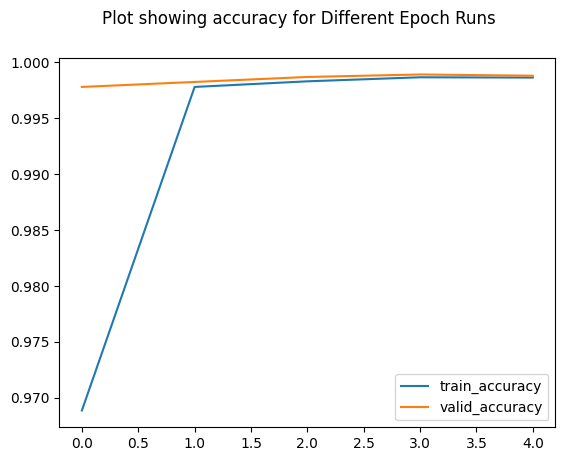

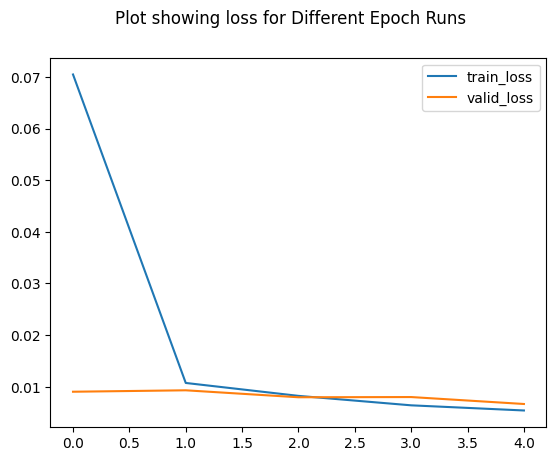

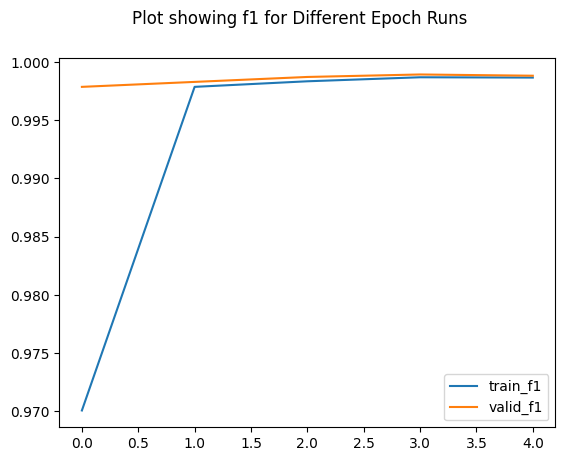

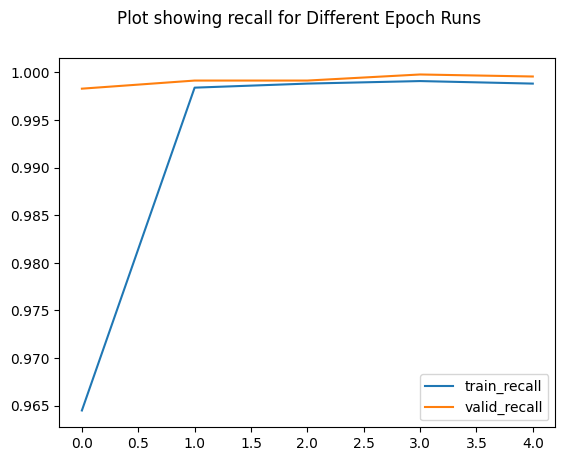

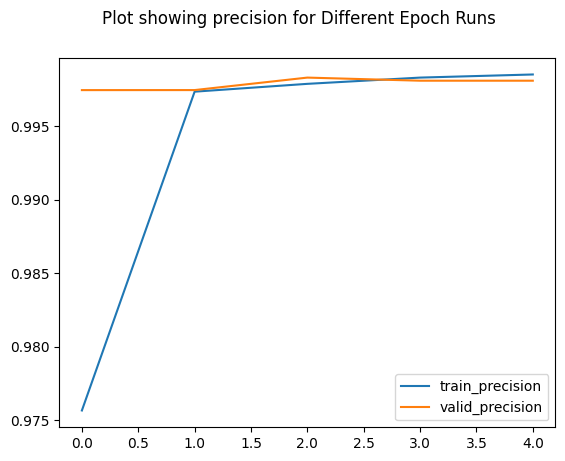

In [ ]:
train_obj.plot_metrics()

In [ ]:
df_test, avg_test_loss, test_accuracy = train_obj.get_test_accuracy()

Test Loss: 0.005252965833687893, Test Accuracy: 0.9983296213808464


In [ ]:
df_test

,orig_label,pred_label
0,0.0,0.0
1,1.0,1.0
2,0.0,0.0
3,0.0,0.0
4,1.0,1.0
...,...,...
3,0.0,0.0
4,1.0,1.0
5,0.0,0.0
6,0.0,0.0


In [ ]:
cm = confusion_matrix(df_test['orig_label'], df_test['pred_label'])

In [ ]:
print(f'Confusion Matrix: \n {cm}  \n Recall: {cm[1,1]/(cm[1,0]+cm[1,1])}')

Confusion Matrix: 
 [[1710    3]
 [   3 1876]]  
 Recall: 0.9984034060670569
